# TP3 : Inférence variationnelle dans le modèle *Latent Dirichlet Allocation*

## G3 SDI - Estimation Avancée

Dans ce dernier TP, on s'intéresse au modèle *Latent Dirichlet Allocation* ([Blei et al. (2003)](https://www.jmlr.org/papers/volume3/blei03a/blei03a.pdf)), un célèbre modèle probabiliste pour données textuelles. Voir le .pdf joint à l'archive pour la description complète du modèle. Dans ce modèle, la loi a posteriori est intractable, et nous utiliserons l'approche variationnelle pour en trouver une approximation.

Using the notations from the .pdf file describing the model, the intractable posterior is :
$$p(\boldsymbol{\beta}, \boldsymbol{\theta} | \mathcal{D}),$$
which we are going to approximate in the following way :
$$\simeq \left[ \prod_{k=1}^K q(\boldsymbol{\beta_k}) \right] \left[ \prod_{d=1}^D q(\boldsymbol{\theta_d}) \right] , $$
with :
* $q(\boldsymbol{\beta_k})$ a Dirichlet distribution (of size V) with variational parameters $[\lambda_{k1}, ...,\lambda_{kV}]$ ;
* $q(\boldsymbol{\theta_d})$ a Dirichlet distribution (of size K) with variational parameters $[\gamma_{d1}, ...,\gamma_{dK}]$.

### Instructions

1. Renommez votre notebook sous la forme `tp3_Nom1_Nom2.ipynb`. 

2. Votre code, ainsi que toute sortie du code, doivent être commentés !

3. Déposez votre notebook sur Moodle dans la section prévue à cet effet avant la date limite.

**Compte rendu — Ugo Roccamatisi.**


In [2]:
# Import usual libraries
import numpy as np
from matplotlib import pyplot as plt

# Specific for this lab
from sklearn.decomposition import LatentDirichletAllocation

**Q0.** À quelle difficulté principale se heurterait un algorithme MCMC dans ce contexte ?

**Réponse.** Un Gibbs est possible grâce à la conjugaison, mais il faudrait mettre à jour les affectations latentes des nombreux mots de tous les documents, ainsi que les distributions topic-mot et document-topic ; le coût et l’autocorrélation des chaînes rendent les calculs lourds à cette échelle. La méthode variationnelle fournit une approximation optimisée plus facilement applicable à tout le corpus.

### Partie 1 - Préparation des données

On utilise le dataset `20newsgroups` (voir par exemple [ici](https://scikit-learn.org/stable/datasets/real_world.html#newsgroups-dataset)), qui contient des messages postés dans différentes catégories sur un forum dans les années 90.

In [6]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
# Cache inclus pour éviter un téléchargement au moment de la réexécution.
newsgroups=fetch_20newsgroups(data_home='./sklearn_data',subset='train').data
print('Documents chargés :',len(newsgroups))

Documents chargés : 11314


**Q1.** En LDA, sous quelle forme est représentée un document ?

**Réponse.** Un document est un sac de mots : un vecteur de longueur V donnant le nombre d’occurrences de chaque mot du vocabulaire. L’ordre des mots est perdu dans ce modèle.

**Q2.** Créer la matrice des données en utilisant la fonction `CountVectorizer` en utilisant les arguments :
* `max_df` = 0.95 ;
* `max_features` = 1000 ;
* `stop_words` = "english".

Expliquer à quoi correspondent ces 3 arguments.

In [10]:
vectorizer=CountVectorizer(max_df=.95,max_features=1000,stop_words='english')
X=vectorizer.fit_transform(newsgroups)
vocab=vectorizer.get_feature_names_out()
print('Matrice documents × mots :',X.shape,'; premiers mots :',vocab[:15])

Matrice documents × mots : (11314, 1000) ; premiers mots : ['00' '000' '01' '02' '03' '04' '0d' '0t' '10' '100' '11' '12' '13' '14'
 '145']


**Réponse.** `max_df=0.95` ignore les termes présents dans plus de 95 % des documents ; `max_features=1000` conserve au plus 1000 mots selon les fréquences du vectoriseur ; `stop_words="english"` retire les mots anglais fréquents peu informatifs.

**Q3.** Rappeler à quoi correspondent les dimensions de la matrice des données obtenues.

Calculer son pourcentage d'éléments non-nuls. Est-ce surprenant ?

In [13]:
density=100*X.nnz/(X.shape[0]*X.shape[1])
print('Observations / mots :',X.shape,'; coefficients non nuls :',X.nnz)
print(f'Densité : {density:.3f} % ; matrice creuse : {100-density:.3f} % de zéros')

Observations / mots : (11314, 1000) ; coefficients non nuls : 499682
Densité : 4.416 % ; matrice creuse : 95.584 % de zéros


**Réponse.** Chaque ligne représente un document et chaque colonne un mot du vocabulaire ; l’entrée est le nombre d’occurrences. La matrice est très creuse car un document n’emploie qu’une petite fraction des 1000 mots retenus.

### Partie 2 - Latent Dirichlet Allocation (LDA)

**Q4.** Entraîner le modèle LDA avec les arguments suivants :
* `n_components` = 8 ;
* `learning_method` = "online" ;
* `max_iter` = 50 ;
* `doc_topic_prior` = 0.1 ;
* `topic_word_prior` = 0.1 ;
* `learning_offset` = 100.

Idem, expliquer à quoi correspondent chacun de ces arguments.

In [17]:
lda=LatentDirichletAllocation(n_components=8,learning_method='online',max_iter=50,
    doc_topic_prior=.1,topic_word_prior=.1,learning_offset=100,
    random_state=0,n_jobs=1)
lda.fit(X)
print('Nombre d’itérations :',lda.n_iter_,'; taille topics × mots :',lda.components_.shape)
print('Perplexité entraînement (indicative, non prédictive) :',lda.perplexity(X))

Nombre d’itérations : 50 ; taille topics × mots : (8, 1000)
Perplexité entraînement (indicative, non prédictive) : 344.59266991208557


**Réponse.** `n_components=8` fixe huit topics ; `learning_method="online"` effectue des mises à jour variationnelles par mini-lots ; `max_iter=50` limite les passages sur le corpus ; `doc_topic_prior=0.1` et `topic_word_prior=0.1` fixent les concentrations Dirichlet α et η (faibles valeurs favorisent des distributions moins uniformes) ; `learning_offset=100` ralentit les premières mises à jour en ligne. La perplexité sur l’entraînement est descriptive et ne suffit pas à choisir K.

**Q5.** Que contient l'attribut `.components` ?

Comment obtenir le MMSE de $\boldsymbol{\beta}$ à partir de cet attribut ? L'implémenter.

In [20]:
# components_[k,v] : paramètre variationnel Dirichlet du mot v pour le topic k.
# Son espérance a posteriori est le paramètre divisé par la somme de sa ligne.
beta_mmse=lda.components_/lda.components_.sum(axis=1,keepdims=True)
print('Dimensions des moyennes topic-mot :',beta_mmse.shape)
print('Sommes par topic :',np.round(beta_mmse.sum(axis=1),8))

Dimensions des moyennes topic-mot : (8, 1000)
Sommes par topic : [1. 1. 1. 1. 1. 1. 1. 1.]


**Réponse.** `.components_` contient les paramètres variationnels λ de la loi Dirichlet de chaque topic sur les mots, pas directement des probabilités normalisées. L’espérance (estimateur MMSE de β sous perte quadratique) est λ_kv / Σ_v λ_kv ; chaque ligne de `beta_mmse` somme à 1.

**Q6.** À partir de $\hat{\boldsymbol{\beta}}_{MMSE}$, afficher les 10 mots les plus courants par topic. Pouvez-vous interpréter les topics obtenus ?

Si vous souhaitez rajouter certains mots à la liste des stop words pour améliorer l'interprétabilité, utilisez le bloc de code ci-dessous.

In [23]:
for k,row in enumerate(beta_mmse):
    words=vocab[np.argsort(row)[-10:][::-1]]
    print(f'Topic {k+1}:',', '.join(words))

Topic 1: space, key, gov, nasa, use, access, chip, netcom, encryption, data
Topic 2: drive, card, edu, use, scsi, ibm, problem, mac, apple, bit
Topic 3: windows, file, edu, 10, 00, program, mail, use, available, 15
Topic 4: edu, university, writes, article, posting, nntp, host, cs, ca, like
Topic 5: god, people, edu, don, think, does, say, just, know, believe
Topic 6: com, writes, article, posting, host, nntp, distribution, hp, ca, reply
Topic 7: ax, max, g9v, b8f, a86, 145, pl, 0d, 1d9, 34u
Topic 8: people, don, said, just, car, like, think, time, know, government


In [24]:
# Extension facultative : personnaliser puis réajuster vectorizer et LDA si besoin.
from sklearn.feature_extraction import text
my_additional_stop_words=[]
my_stop_words=text.ENGLISH_STOP_WORDS.union(my_additional_stop_words)
print('Mots supplémentaires ignorés dans la version actuelle :',my_additional_stop_words)

Mots supplémentaires ignorés dans la version actuelle : []


**Réponse.** Les topics 1 à 3 évoquent l’espace et la cryptographie, le matériel informatique, puis Windows et les logiciels. Le topic 5 évoque la religion ; le topic 8 mêle conversations générales, voitures et gouvernement. Les topics 4 et 6 capturent surtout les en-têtes des messages (`edu`, `writes`, `article`, `nntp`, `host`). Le topic 7 rassemble des chaînes alphanumériques (`ax`, `g9v`, etc.) plutôt qu’un thème lisible : cela signale du bruit ou du contenu encodé. Retirer les en-têtes, signatures et citations, puis ajuster les mots vides, améliorerait probablement l’interprétation ; un nouveau prétraitement impose de réentraîner le modèle.


**Q7.** Que contient `lda.transform(X)` ?

Regarder si les documents sont en général plutôt associés à un ou plusieurs topics.

Taille documents × topics : (11314, 8)
Sommes des proportions (5 documents) : [1. 1. 1. 1. 1.]
Proportion avec topic dominant > 0,5 : 0.6552059395439279
Nombre moyen de topics par document avec part > 0,2 : 1.8468269400742443


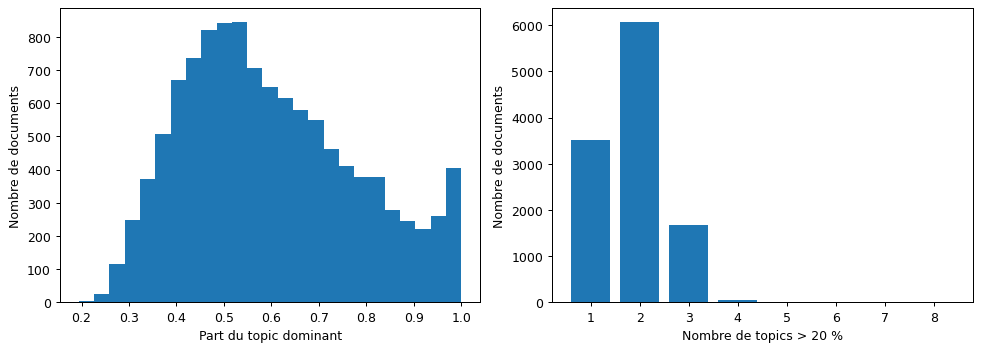

In [27]:
doc_topic=lda.transform(X)
max_probability=doc_topic.max(axis=1)
number_above_20=(doc_topic>.20).sum(axis=1)
print('Taille documents × topics :',doc_topic.shape)
print('Sommes des proportions (5 documents) :',np.round(doc_topic[:5].sum(axis=1),6))
print('Proportion avec topic dominant > 0,5 :',np.mean(max_probability>.5))
print('Nombre moyen de topics par document avec part > 0,2 :',number_above_20.mean())
fig,axes=plt.subplots(1,2,figsize=(11,4))
axes[0].hist(max_probability,bins=25);axes[0].set(xlabel='Part du topic dominant',ylabel='Nombre de documents')
axes[1].bar(np.arange(1,9),np.bincount(number_above_20,minlength=9)[1:]);axes[1].set(xlabel='Nombre de topics > 20 %',ylabel='Nombre de documents')
fig.tight_layout();plt.show()

**Réponse.** `lda.transform(X)` renvoie une distribution estimée sur les huit topics pour chaque document, dont la somme vaut 1. Ici, environ **65,5 %** des documents ont un topic dominant de poids supérieur à 0,5 et il y a en moyenne **1,85 topic** de poids supérieur à 0,2 par document. Certains documents mélangent donc plusieurs thèmes.


### Partie 3 - Pour aller plus loin...

Répondre aux questions sans implémenter les solutions discutées.

**Q8.** Quelle est l'influence des paramètres $\alpha$ et $\eta$ ?

**Réponse.** α faible rend les documents principalement associés à peu de topics ; α élevé les mélange davantage. η faible concentre chaque topic sur peu de mots ; η élevé le diffuse sur davantage de termes. Leur effet dépend aussi de la taille du corpus et du vocabulaire.

**Q9.** Pour aujourd'hui, le nombre de topics $K$ était fixé à l'avance. Comment pourrait-on apprendre ou choisir la valeur de $K$ ?

**Réponse.** Entraîner plusieurs valeurs de K avec les mêmes règles de préparation et comparer une perplexité sur des documents tenus à l’écart ; examiner également la cohérence/interprétabilité des mots et la stabilité des topics. Des modèles non paramétriques peuvent aussi apprendre une complexité variable.

**Q10.** Quelles sont les principales limites du modèle LDA et quelles potentielles améliorations proposez-vous ?

**Réponse.** Le sac de mots ignore l’ordre et le contexte : polysémie, négation et expressions sont mal représentées. K fixé et topics indépendants des métadonnées limitent aussi le modèle. Des n-grammes, des modèles dynamiques ou hiérarchiques, et des représentations contextuelles peuvent mieux tenir compte de ces informations.